In [2]:
main_df <- read.csv("/northstar_integrated_cleaned.csv")

print("Dataset loaded successfully")
dim(main_df)
head(main_df)

[1] "Dataset loaded successfully"


[1] 1250   72

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,maintenance_status_vehicle,telematics_version_vehicle,complaint_count,avg_resolution_days,total_compensation,complaint_flag,incident_count,avg_resolved_hours,incident_flag,delay_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,⋯,InRepair,v2.0,0,0,0.00,0,0,0,0,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,⋯,,,0,0,0.00,0,0,0,0,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,⋯,Active,v2.0,1,2,8.66,1,0,0,0,1
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,⋯,Active,v2.2,0,0,0.00,0,0,0,0,0
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,⋯,Active,v2.1,1,8,54.41,1,0,0,0,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,Central,East,High,151.44,Web,⋯,,,0,0,0.00,0,0,0,0,0


In [3]:
names(main_df)

[1] "order_id"                      "customer_id"                  
 [3] "service_type"                  "order_created_at"             
 [5] "promised_window_hours"         "pickup_zone"                  
 [7] "dropoff_zone"                  "priority_level"               
 [9] "order_value"                   "booking_channel"              
[11] "special_handling_flag"         "delivery_id"                  
[13] "driver_id"                     "vehicle_id"                   
[15] "hub_id"                        "dispatch_time"                
[17] "delivery_completed_at"         "delivery_status"              
[19] "route_distance_km"             "manual_route_override_count"  
[21] "proof_of_completion_missing"   "customer_rating_post_delivery"
[23] "fuel_or_charge_cost"           "actual_delivery_hours"        
[25] "age"                           "home_zone"                    
[27] "customer_type"                 "signup_date"                  
[29] "loyalty_score"                 "app_engagement_score"         
[31] "preferred_channel"             "account_status"               
[33] "hub_name"                      "zone"                         
[35] "hub_type"                      "capacity_score"               
[37] "base_zone"                     "employment_type"              
[39] "years_experience"              "training_score"               
[41] "driver_rating"                 "shift_preference"             
[43] "active_flag"                   "base_zone_driver"             
[45] "employment_type_driver"        "years_experience_driver"      
[47] "training_score_driver"         "driver_rating_driver"         
[49] "shift_preference_driver"       "active_flag_driver"           
[51] "vehicle_type"                  "assigned_zone"                
[53] "commission_date"               "battery_health_pct"           
[55] "odometer_km"                   "maintenance_status"           
[57] "telematics_version"            "vehicle_type_vehicle"         
[59] "assigned_zone_vehicle"         "commission_date_vehicle"      
[61] "battery_health_pct_vehicle"    "odometer_km_vehicle"          
[63] "maintenance_status_vehicle"    "telematics_version_vehicle"   
[65] "complaint_count"               "avg_resolution_days"          
[67] "total_compensation"            "complaint_flag"               
[69] "incident_count"                "avg_resolved_hours"           
[71] "incident_flag"                 "delay_flag"

In [4]:
install.packages("sqldf")
library(sqldf)
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
query1 <- sqldf("
SELECT service_type, delivery_status, COUNT(*) AS total_deliveries
FROM main_df
GROUP BY service_type, delivery_status
ORDER BY service_type, total_deliveries DESC
")

query1

service_type,delivery_status,total_deliveries
<chr>,<chr>,<int>
Business,OnTime,73
Business,,39
Business,Delayed,28
Business,Failed,25
Medical,OnTime,70
Medical,,31
Medical,Delayed,22
Medical,Failed,16
Parcel,OnTime,156


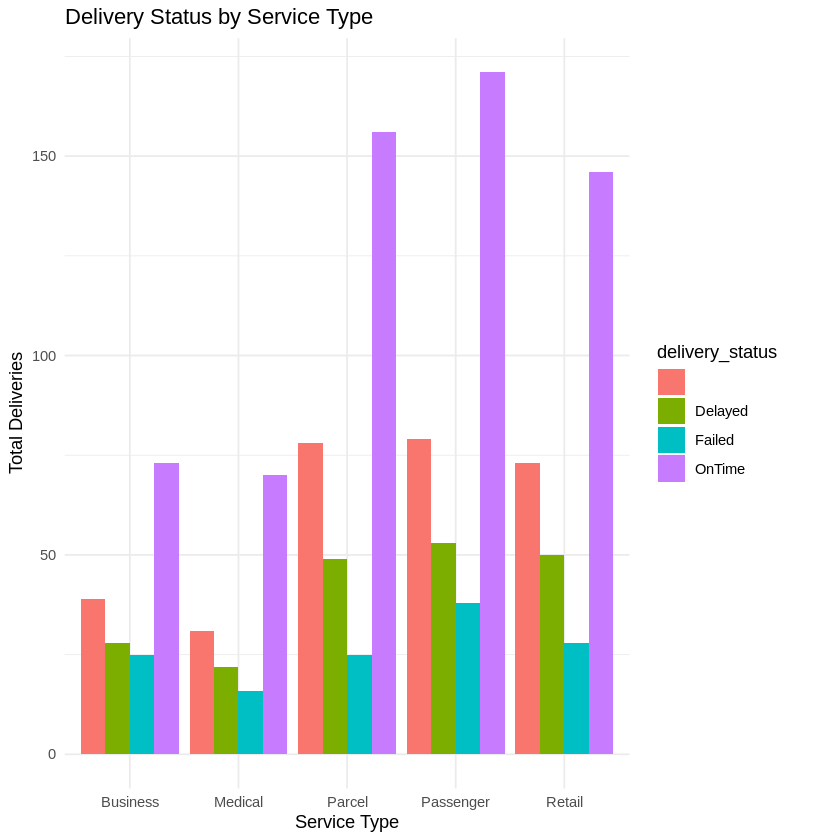

In [6]:
ggplot(query1, aes(x = service_type, y = total_deliveries, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Delivery Status by Service Type",
    x = "Service Type",
    y = "Total Deliveries"
  ) +
  theme_minimal()

In [7]:
query2 <- sqldf("
SELECT hub_name, AVG(actual_delivery_hours) AS avg_delivery_hours
FROM main_df
GROUP BY hub_name
ORDER BY avg_delivery_hours DESC
")

query2

hub_name,avg_delivery_hours
<chr>,<dbl>
Central Core,11.553300
West Gate,11.102635
North Exchange,10.684968
Midtown Relay,10.560490
Riverside Hub,10.535888
Airport Hub,9.917423
South Link,9.478948
East Dock,8.437893
,NA


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


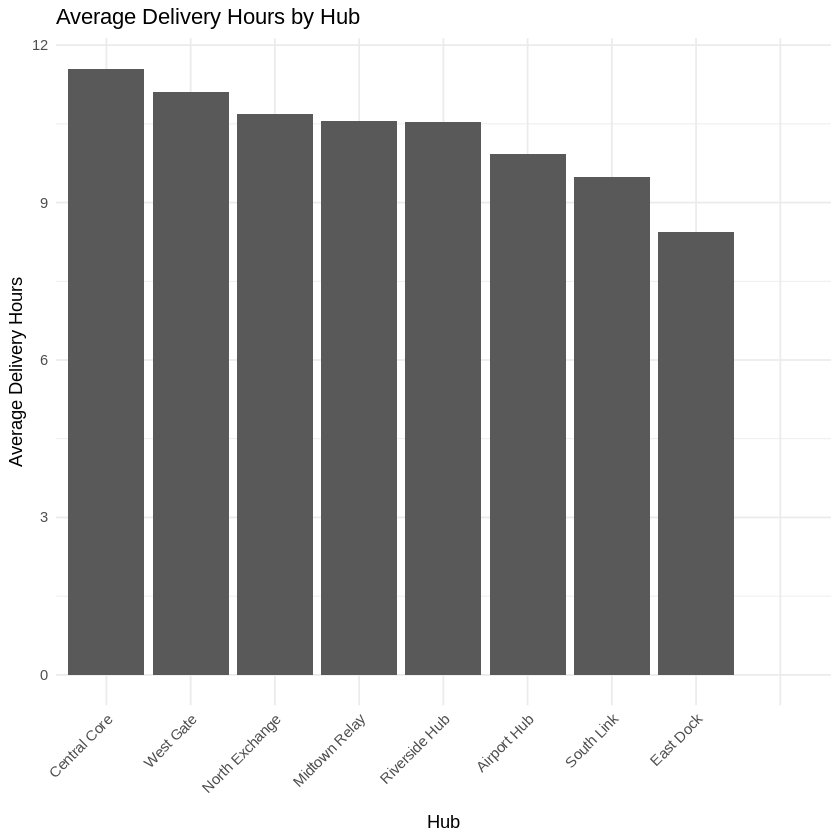

In [8]:
ggplot(query2, aes(x = reorder(hub_name, -avg_delivery_hours), y = avg_delivery_hours)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Delivery Hours by Hub",
    x = "Hub",
    y = "Average Delivery Hours"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [9]:
query3 <- sqldf("
SELECT service_type,
       COUNT(*) AS total_orders,
       SUM(complaint_flag) AS complaint_orders,
       ROUND(AVG(complaint_flag) * 100, 2) AS complaint_rate
FROM main_df
GROUP BY service_type
ORDER BY complaint_rate DESC
")

query3

service_type,total_orders,complaint_orders,complaint_rate
<chr>,<int>,<int>,<dbl>
Retail,297,72,24.24
Medical,139,33,23.74
Passenger,341,77,22.58
Parcel,308,69,22.40
Business,165,34,20.61


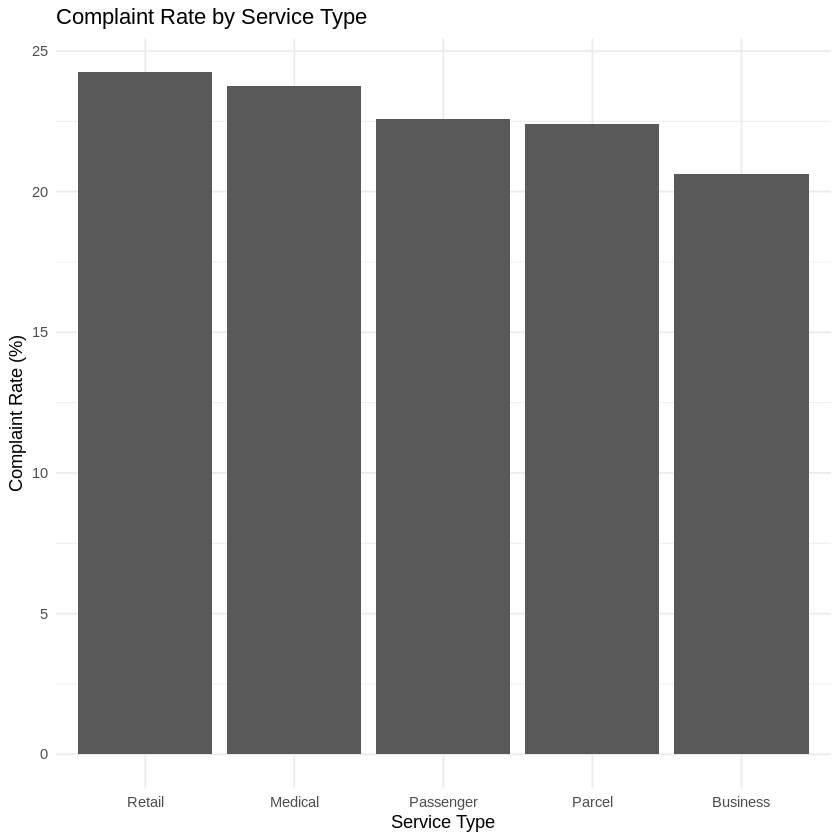

In [10]:
ggplot(query3, aes(x = reorder(service_type, -complaint_rate), y = complaint_rate)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaint Rate by Service Type",
    x = "Service Type",
    y = "Complaint Rate (%)"
  ) +
  theme_minimal()

In [11]:
query4 <- sqldf("
SELECT manual_route_override_count,
       COUNT(*) AS total_deliveries,
       SUM(delay_flag) AS delayed_deliveries,
       ROUND(AVG(delay_flag) * 100, 2) AS delay_rate
FROM main_df
GROUP BY manual_route_override_count
ORDER BY manual_route_override_count
")

query4

manual_route_override_count,total_deliveries,delayed_deliveries,delay_rate
<dbl>,<int>,<int>,<dbl>
NA,300,0,0.00
0,399,175,43.86
1,310,152,49.03
2,153,67,43.79
3,57,28,49.12
4,23,9,39.13
5,7,4,57.14
7,1,0,0.00


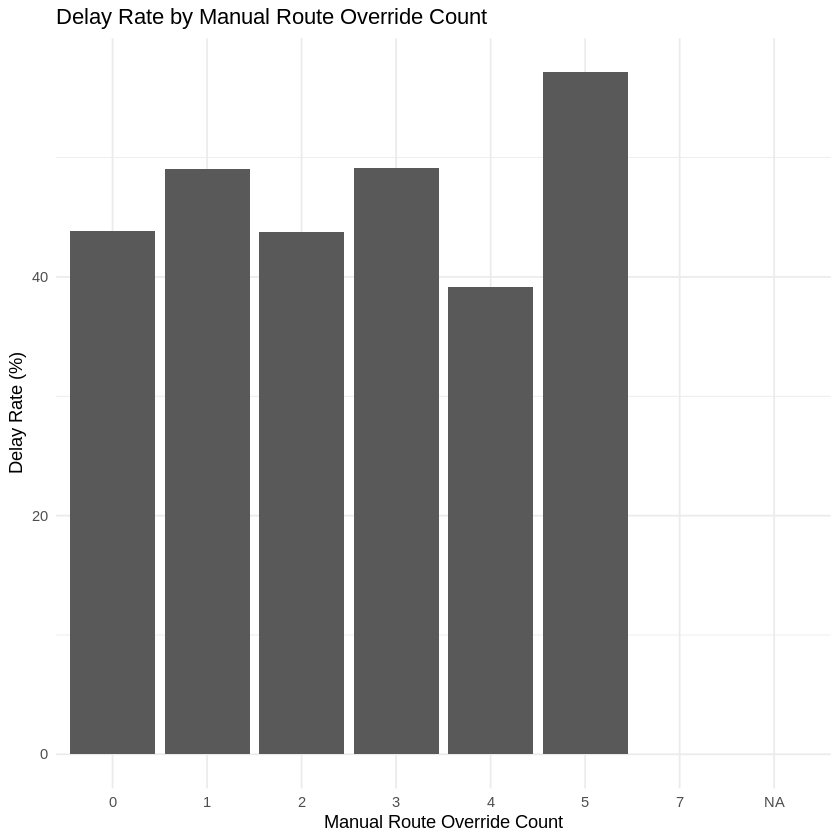

In [12]:
ggplot(query4, aes(x = as.factor(manual_route_override_count), y = delay_rate)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Delay Rate by Manual Route Override Count",
    x = "Manual Route Override Count",
    y = "Delay Rate (%)"
  ) +
  theme_minimal()

In [13]:
query5 <- sqldf("
SELECT maintenance_status,
       delivery_status,
       COUNT(*) AS total_deliveries
FROM main_df
GROUP BY maintenance_status, delivery_status
ORDER BY maintenance_status, total_deliveries DESC
")

query5

maintenance_status,delivery_status,total_deliveries
<chr>,<chr>,<int>
,,300
Active,OnTime,384
Active,Delayed,113
Active,Failed,45
InRepair,OnTime,125
InRepair,Failed,77
InRepair,Delayed,52
Scheduled,OnTime,107
Scheduled,Delayed,37


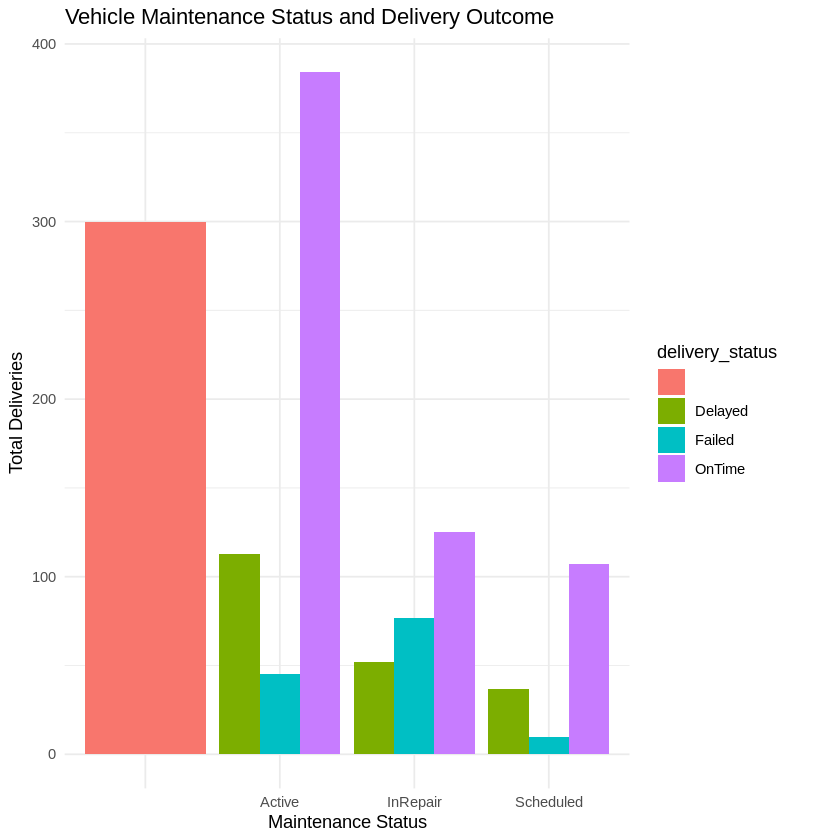

In [14]:
ggplot(query5, aes(x = maintenance_status, y = total_deliveries, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Vehicle Maintenance Status and Delivery Outcome",
    x = "Maintenance Status",
    y = "Total Deliveries"
  ) +
  theme_minimal()

In [15]:
names(main_df)[grepl("cost", names(main_df), ignore.case = TRUE)]

[1] "fuel_or_charge_cost"

In [16]:
query6 <- sqldf("
SELECT service_type,
       ROUND(AVG(fuel_or_charge_cost), 2) AS avg_cost
FROM main_df
GROUP BY service_type
ORDER BY avg_cost DESC
")

query6

service_type,avg_cost
<chr>,<dbl>
Business,13.14
Parcel,13.08
Retail,12.97
Medical,12.77
Passenger,12.40


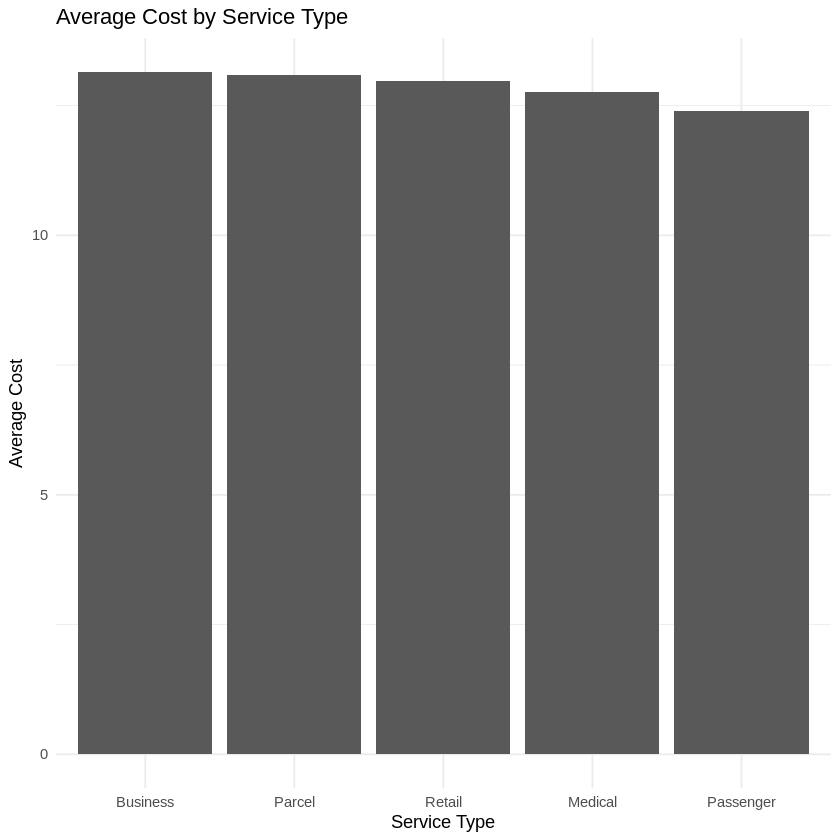

In [17]:
ggplot(query6, aes(x = reorder(service_type, -avg_cost), y = avg_cost)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Cost by Service Type",
    x = "Service Type",
    y = "Average Cost"
  ) +
  theme_minimal()

In [18]:
query7 <- sqldf("
SELECT service_type,
       COUNT(*) AS total_orders,
       SUM(incident_flag) AS incident_orders,
       ROUND(AVG(incident_flag) * 100, 2) AS incident_rate
FROM main_df
GROUP BY service_type
ORDER BY incident_rate DESC
")

query7

service_type,total_orders,incident_orders,incident_rate
<chr>,<int>,<int>,<dbl>
Business,165,41,24.85
Retail,297,66,22.22
Passenger,341,62,18.18
Parcel,308,56,18.18
Medical,139,23,16.55


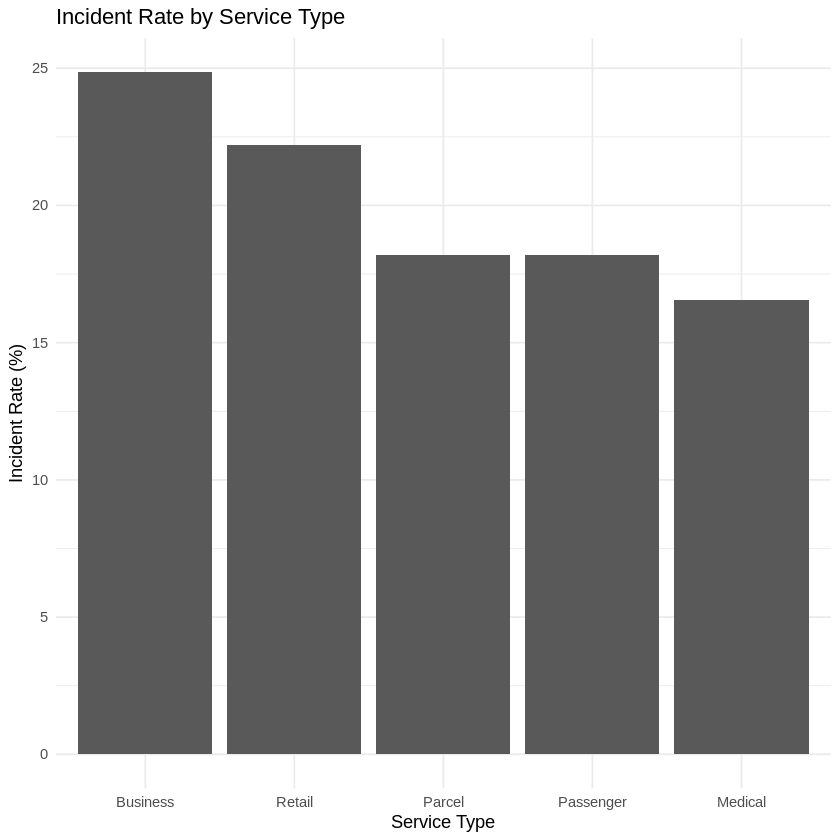

In [20]:
ggplot(query7, aes(x = reorder(service_type, -incident_rate), y = incident_rate)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Incident Rate by Service Type",
    x = "Service Type",
    y = "Incident Rate (%)"
  ) +
  theme_minimal()

In [22]:
write.csv(query1, "/content/query1_delivery_status_by_service.csv", row.names = FALSE)
write.csv(query2, "/content/query2_avg_delivery_hours_by_hub.csv", row.names = FALSE)
write.csv(query3, "/content/query3_complaint_rate_by_service.csv", row.names = FALSE)
write.csv(query4, "/content/query4_route_override_delay.csv", row.names = FALSE)
write.csv(query5, "/content/query5_vehicle_maintenance_delivery.csv", row.names = FALSE)
write.csv(query6, "/content/query6_avg_cost_by_service.csv", row.names = FALSE)
write.csv(query7, "/content/query7_incident_rate_by_service.csv", row.names = FALSE)

print("All R SQL query outputs saved successfully.")

[1] "All R SQL query outputs saved successfully."
